# **Juan Andres Duarte**
# **200547253**

# **Project: Smart Health & Lifestyle Prediction System (Weeks 1–11)**

# **Activity Part 1 — Load & Explore Dataset**

In [1]:
# Upload project_health_dataset.csv
from google.colab import files
uploaded = files.upload()

Saving project_health_dataset.csv to project_health_dataset (2).csv


In [2]:

# TODO 1: Load dataset (project_health_dataset.csv) using pandas

import pandas as pd

df = pd.read_csv('project_health_dataset.csv')

# TODO 2: Preview first 5 rows

print("First 5 rows:")
print(df.head())


# TODO 3: Check dataset info, missing values, duplicates

print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:")
print(df.duplicated().sum())

# TODO 4: Describe statistical summary of numerical features

print("\nSummary numerical features:")
print(df.describe())




First 5 rows:
   Age  Gender  HoursExercise  HoursSleep  DietScore  StressLevel   BMI  \
0   56    Male             13           5          7            3  18.9   
1   46  Female              4           4          1            5  34.3   
2   32  Female              0           7          3            6  32.4   
3   25  Female              2           7          2            9  24.0   
4   38    Male              9           4          9            5  34.3   

   HealthScore  
0            0  
1            0  
2            1  
3            1  
4            0  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            100 non-null    int64  
 1   Gender         100 non-null    object 
 2   HoursExercise  100 non-null    int64  
 3   HoursSleep     100 non-null    int64  
 4   DietScore      100 non-null    int64  
 5   StressLeve

# **Activity Part 2 — Data Cleaning & Feature Engineering**

In [3]:
# TODO 5: Fill missing numerical values with mean

df = df.fillna(df.mean(numeric_only=True))

# TODO 6: Fill missing categorical values with mode

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

# TODO 7: Remove duplicates

df = df.drop_duplicates()

# TODO 8: Create new features:
#         WellnessIndex = HoursExercise * HoursSleep
#         BMI Category: Underweight, Normal, Overweight, Obese

df["WellnessIndex"] = df["HoursExercise"] * df["HoursSleep"]
df["BMI_Category"] = df["BMI"].apply(lambda x: "Underweight" if x < 18.5 else "Normal" if x < 25 else "Overweight" if x < 30 else "Obese")


# Reset the columns in the df so add the encoded columns can be run multiple times
df = df[[ "Age", "Gender", "HoursExercise", "HoursSleep", "DietScore", "StressLevel", "BMI", "HealthScore", "WellnessIndex", "BMI_Category"]]


# TODO 9: Encode categorical variables (Gender, BMI Category)

df_encoded_gender = pd.get_dummies(df["Gender"])
df_encoded_BMI_Category = pd.get_dummies(df["BMI_Category"])

# Add encoded columns to df

df = pd.concat([df, df_encoded_gender, df_encoded_BMI_Category], axis=1)
df.head()


,Age,Gender,HoursExercise,HoursSleep,DietScore,StressLevel,BMI,HealthScore,WellnessIndex,BMI_Category,Female,Male,Normal,Obese,Overweight
0,56,Male,13,5,7,3,18.9,0,65,Normal,False,True,True,False,False
1,46,Female,4,4,1,5,34.3,0,16,Obese,True,False,False,True,False
2,32,Female,0,7,3,6,32.4,1,0,Obese,True,False,False,True,False
3,25,Female,2,7,2,9,24.0,1,14,Normal,True,False,True,False,False
4,38,Male,9,4,9,5,34.3,0,36,Obese,False,True,False,True,False


# **Activity Part 3 — Data Visualization**

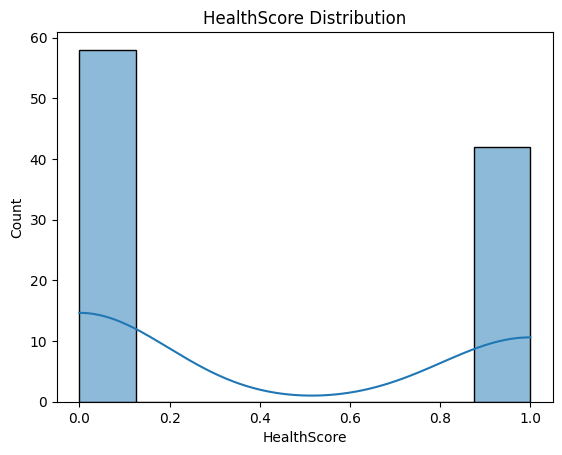

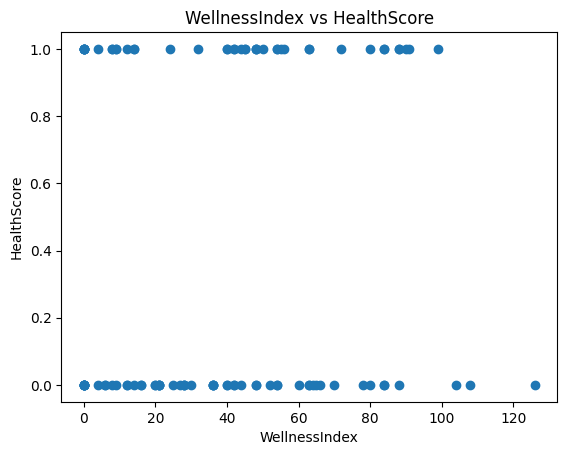

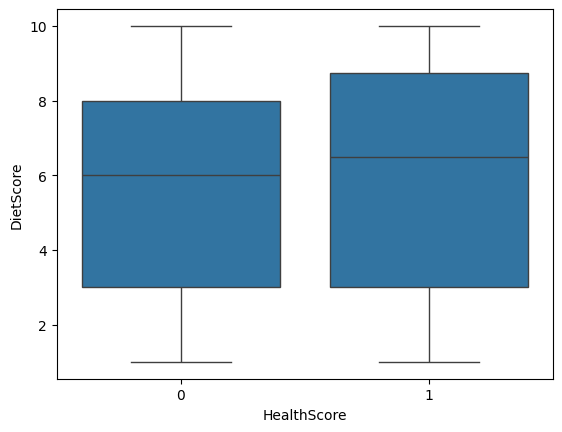

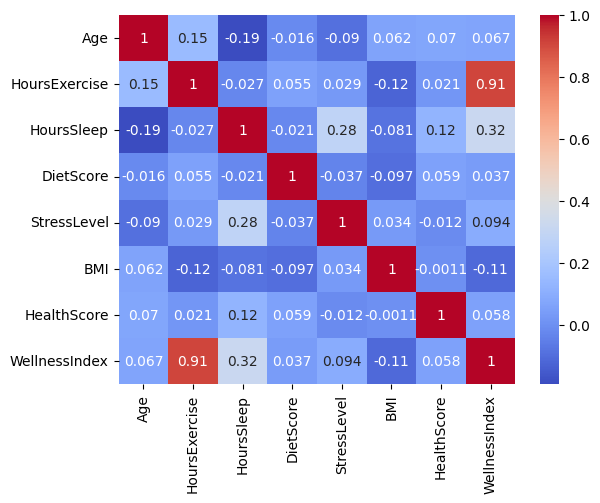

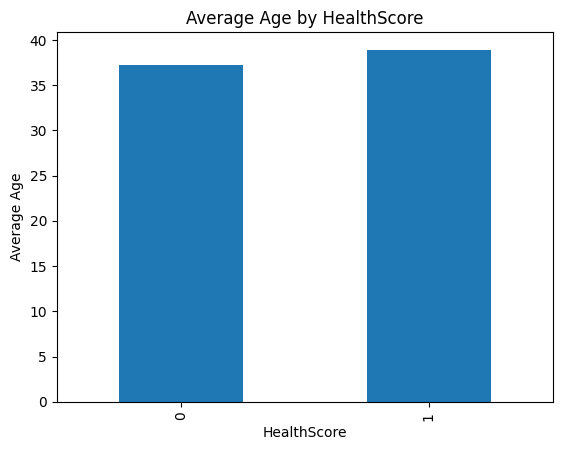

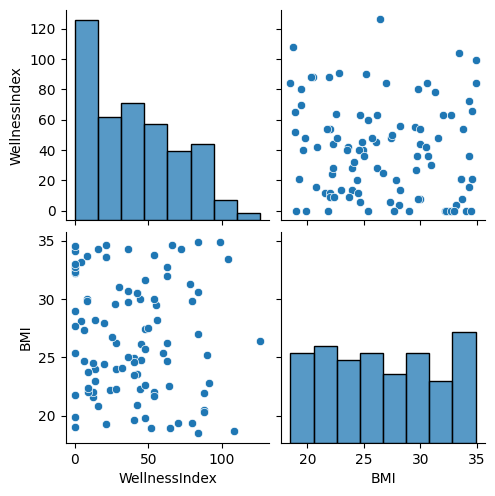

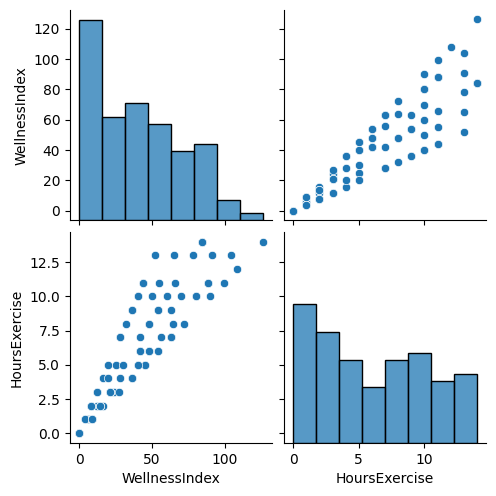

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO 10: Histogram of HealthScore

sns.histplot(df["HealthScore"], kde=True)
plt.title("HealthScore Distribution")
plt.show()

# TODO 11: Scatter plot: WellnessIndex vs HealthScore

plt.scatter(df["WellnessIndex"], df["HealthScore"])
plt.title("WellnessIndex vs HealthScore")
plt.xlabel("WellnessIndex")
plt.ylabel("HealthScore")
plt.show()

# TODO 12: Boxplot: DietScore vs HealthScore

sns.boxplot(x=df["HealthScore"], y=df["DietScore"])
plt.show()


# TODO 13: Heatmap of feature correlations

corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# TODO 14: Any other visualizations to explore patterns

# Bar Chart — Average Age by HealthScore
avg_BMI = df.groupby("HealthScore")["Age"].mean()
avg_BMI.plot(kind="bar")
plt.title("Average Age by HealthScore")
plt.xlabel("HealthScore")
plt.ylabel("Average Age")
plt.show()

# BPairplot WellnessIndex vs BMI Analysis
sns.pairplot(df, vars=["WellnessIndex", "BMI",])
plt.show()

# BPairplot WellnessIndex vs HoursExercise Analysis
sns.pairplot(df, vars=["WellnessIndex", "HoursExercise",])
plt.show()

# **Activity Part 4 — Supervised Machine Learning**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# TODO 15: Split dataset into X (features) and y (HealthScore)

X = df[["Age", "HoursExercise", "HoursSleep", "DietScore", "StressLevel", "BMI", "WellnessIndex", "Female", "Male", "Normal", "Obese", "Overweight"]]
y = df['HealthScore']


# TODO 16: Split data into train/test sets (80/20)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# TODO 17: Train KNN model, evaluate accuracy, confusion matrix, classification report

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("\nAccuracy KNN model:\n", accuracy_score(y_test, y_pred))
print("\nConfusion matrix KNN model:\n",confusion_matrix(y_test, y_pred))
print("\nClassification Report KNN model:\n", classification_report(y_test, y_pred))


# TODO 18: Train Random Forest, Logistic Regression, and SVM models

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

lr = LogisticRegression(max_iter=487)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


# TODO 19: Compare models using accuracy and F1-score

results = {
    "Model": ["KNN", "Random Forest", "Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1-score": [
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro')
    ]
}

df_compare = pd.DataFrame(results)
print("\nComparation models:\n", df_compare)


Accuracy KNN model:
 0.6

Confusion matrix KNN model:
 [[8 2]
 [6 4]]

Classification Report KNN model:
               precision    recall  f1-score   support

           0       0.57      0.80      0.67        10
           1       0.67      0.40      0.50        10

    accuracy                           0.60        20
   macro avg       0.62      0.60      0.58        20
weighted avg       0.62      0.60      0.58        20


Comparation models:
                  Model  Accuracy  F1-score
0                  KNN      0.60  0.583333
1        Random Forest      0.55  0.487179
2  Logistic Regression      0.65  0.626667
3                  SVM      0.50  0.333333


# **Activity Part 5 — Neural Network Programming**

First Standardize features
 [[ 1.48788435  1.62062407 -0.92087456  0.36209028 -0.73889016 -1.58432274
   0.83601639 -0.86855395  0.86855395  1.15133896 -0.68599434 -0.57735027]
 [ 0.66539438 -0.46006304 -1.48582828 -1.63106722 -0.0907409   1.53251045
  -0.77107671  1.15133896 -1.15133896 -0.86855395  1.45773797 -0.57735027]
 [-0.48609157 -1.38481286  0.20903288 -0.96668139  0.23333373  1.1479661
  -1.29584181  1.15133896 -1.15133896 -0.86855395  1.45773797 -0.57735027]
 [-1.06183455 -0.92243795  0.20903288 -1.2988743   1.20555762 -0.55212474
  -0.83667235  1.15133896 -1.15133896  1.15133896 -0.68599434 -0.57735027]
 [ 0.00740241  0.69587424 -1.48582828  1.02647611 -0.0907409   1.53251045
  -0.11512034 -0.86855395  0.86855395 -0.86855395  1.45773797 -0.57735027]]
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3793 - val_loss: 0.6326
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3549 - val_loss: 0.5846
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3341 - val_loss: 0.5467
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3205 - val_loss: 0.5130
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3052 - val_loss: 0.4898
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2962 - val_loss: 0.4688
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2882 - val_loss: 0.4500
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2816 - val_loss: 0.4346
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2762 - val_loss: 0.4234
Epoch 10/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2725 - val_loss: 0.4097
Epoch 11/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2670 - val_loss: 0.4005
Epoch 12/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2633 - val_loss: 0.392

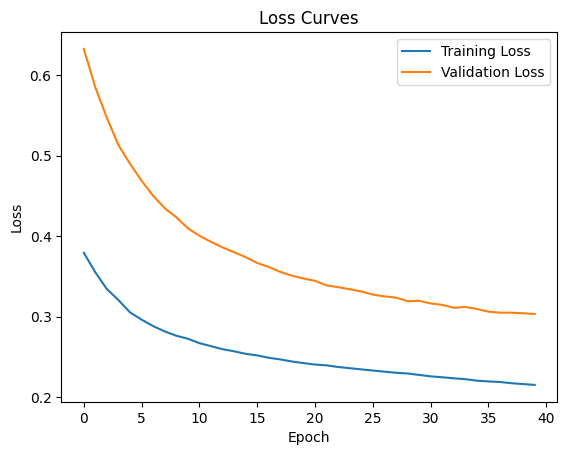

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Confusion Matrix (Neural Network):
[[10  0]
 [ 8  2]]


In [6]:

# NOTE: This project covers concepts from classes 1-11, but I had to use methods from class 12 to properly train and validate the model.


# TODO 20: Standardize features using StandardScaler

import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First Standardize features\n", X_scaled[:5])
y_binary = np.where(df['HealthScore'] == "Healthy", 1, 0).reshape(-1,1)


# TODO 21: Build a simple feedforward neural network (1-2 hidden layers)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(5, input_dim=X_scaled.shape[1], activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse')


# TODO 22: Train network on training data, validate on test data

X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2, random_state=42)

mf = model.fit( X_train, y_train, validation_data=(X_test, y_test), epochs=40, batch_size=8, verbose=1)

loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)


# TODO 23: Plot loss and accuracy curves

#  Note:  Accuracy metric does not apply because this is a regression task (Activity Part 5); only loss is computed.

plt.plot(mf.history['loss'], label='Training Loss')
plt.plot(mf.history['val_loss'], label='Validation Loss')
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# TODO 24: Evaluate predictions using confusion matrix

y_pred_nn = model.predict(X_test)
y_pred_nn_class = y_pred_nn.round().astype(int)
cm_nn = confusion_matrix(y_test, y_pred_nn_class)

print("Confusion Matrix (Neural Network):")
print(cm_nn)


# **Activity Part 6 — K-Fold Cross-Validation**


In [7]:
# TODO 25: Implement K-Fold (k=5 or 10) on one ML model (e.g., Random Forest)

from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

cv_scores = cross_val_score(rf, X, y, cv=10)


# TODO 26: Record mean accuracy and variance across folds

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Variance:", np.var(cv_scores))

CV Scores: [0.7 0.5 0.6 0.5 0.5 0.8 0.3 0.7 0.3 0.2]
Mean CV Accuracy: 0.51
Variance: 0.0349


# **Activity Part 7 — Dimensionality Reduction**

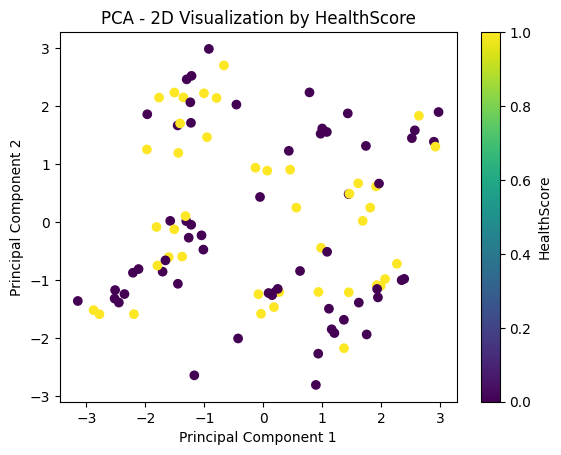

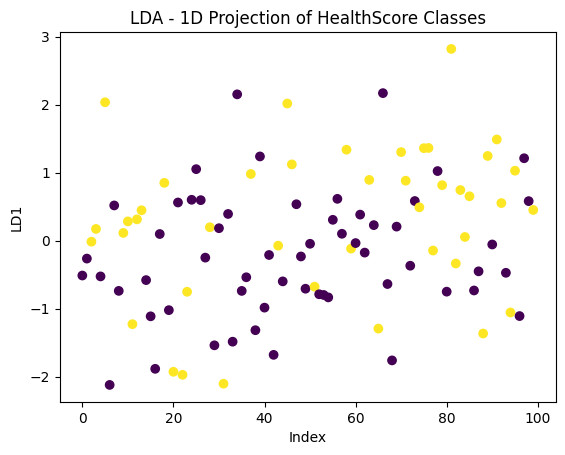

In [8]:
# TODO 27: Apply PCA to reduce features to 2 components

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)


# TODO 28: Visualize first 2 PCA components with color by HealthScore

plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization by HealthScore")
plt.colorbar(label='HealthScore')
plt.show()


# TODO 29: Apply LDA (if supervised) to separate classes

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=1)
lda_result = lda.fit_transform(X_scaled, y)

plt.scatter(range(len(lda_result)), lda_result, c=y, cmap='viridis')
plt.xlabel("Index")
plt.ylabel("LD1")
plt.title("LDA - 1D Projection of HealthScore Classes")
plt.show()

# TODO 30: Compare PCA vs LDA scatter plots

# PCA shows does not separate classes well; LDA tries to separate classes, but
# some overlap remains. However, LDA seems to perform slightly better than PCA.


# **Activity Part 8 — Insights & Recommendations**

### **TODO 31: Summarize observations from visualizations**

##### The histogram shows only two possible outcomes for HealthScore, with a majority of negative cases in a roughly 60-40 proportion. In the scatterplot, no clear trend is observed between WellnessIndex and HealthScore values; they are not directly connected. The boxplot shows higher DietScore values for cases where HealthScore is 1 compared to cases with 0. In the heatmap, the strongest correlation is observed between HoursExercise and WellnessIndex, while the weakest correlation occurs between HoursSleep and StressLevel. The bar chart shows a slightly higher average age for cases where HealthScore is 1. The LCA plot separates the classes somewhat better than PCA in the observed case.


### **TODO 32: Compare model performances, explain best model**

##### Four models were evaluated for predicting HealthScore: KNN, Random Forest, Logistic Regression, and SMV. Their performance metrics are as follows:
#####                   Model  Accuracy  F1-score
##### 0                  KNN      0.60  0.583333
##### 1        Random Forest      0.55  0.487179
##### 2  Logistic Regression      0.65  0.626667
##### 3                  SVM      0.50  0.333333
##### Among these, Logistic Regression performed the best, achieving the highest accuracy and F1-score. The model was trained using max_iter=487, which was chosen to ensure that the algorithm converged properly. This convergence contributed to the model achieving optimal performance on the test set.


### **TODO 33: Suggest lifestyle improvements based on predictions**

##### Although a strong correlation between the target (HealthScore) and the different features was not observed, there is a noticeable positive correlation between better health and HoursExercise, HoursSleep, and DietScore. Therefore, the suggested lifestyle improvements to enhance overall health include regular exercise, sufficient sleep, and maintaining a balanced diet.